# Model Predictions (cavity_claw_RouteMeander_eigenmode)
## eigenmode --> Qiskit Metal

Inverse model with surrogate-defined loss

## Configuration

In [1]:
# The parameter file is where the hyperparameters are set. 
# It's reccomended to look at that file first, its interesting and you can set stuff there

from parameters_surrogate_defined_loss import *

## Library

In [2]:
import os, gc, math
from pathlib import Path
import numpy as np
import pandas as pd
from pandas import json_normalize
import joblib
import matplotlib.pyplot as plt

os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices'
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Dense

## Dataset

### Load

In [3]:
# Load the data saved from ml_00 notebook

# inputs are the eigenmode values (what we want to invert)
X_train = np.load(f'{DATA_DIR}/npy/x_train_one_hot_encoding_augmented.npy', allow_pickle=True)
X_val   = np.load(f'{DATA_DIR}/npy/x_val_one_hot_encoding_augmented.npy', allow_pickle=True)
X_test  = np.load(f'{DATA_DIR}/npy/x_test_one_hot_encoding_augmented.npy', allow_pickle=True)

# Qiskit Metal params (all continuous for transmon cross)
y_train = np.load(f'{DATA_DIR}/npy/y_train_one_hot_encoding_augmented.npy', allow_pickle=True)
y_val   = np.load(f'{DATA_DIR}/npy/y_val_one_hot_encoding_augmented.npy', allow_pickle=True)
y_test  = np.load(f'{DATA_DIR}/npy/y_test_one_hot_encoding_augmented.npy', allow_pickle=True)

# column names
with open('X_names', 'r') as f:
    eigenmode_column_names = f.read().splitlines()

qiskit_param_names = np.load('y_columns.npy', allow_pickle=True).astype(str).tolist()

print(f'Inputs (eigenmode):     {X_train.shape[1]} columns')
print(f'Outputs (Qiskit params):  {y_train.shape[1]} columns')
print(f'\neigenmode columns:  {eigenmode_column_names}')
print(f'Qiskit param columns: {qiskit_param_names}')

Inputs (Hamiltonian):     2 columns
Outputs (Qiskit params):  3 columns

Hamiltonian columns:  ['qubit_frequency_GHz', 'anharmonicity_MHz']
Qiskit param columns: ['design_options.connection_pads.readout.claw_length', 'design_options.connection_pads.readout.ground_spacing', 'design_options.cross_length']


### Define conversion layer

In [4]:
# Must define this class before loading the saved combined model
class ScalerConversionLayer(tf.keras.layers.Layer):
    def __init__(self, scale_a, scale_b, **kwargs):
        kwargs.setdefault('trainable', False)
        super().__init__(**kwargs)
        self._scale_a = tf.constant(scale_a, dtype=tf.float32)
        self._scale_b = tf.constant(scale_b, dtype=tf.float32)
        self._cfg = dict(
            scale_a=list(scale_a) if hasattr(scale_a, '__iter__') else scale_a,
            scale_b=list(scale_b) if hasattr(scale_b, '__iter__') else scale_b)

    def call(self, inputs):
        a = tf.cast(self._scale_a, inputs.dtype)
        b = tf.cast(self._scale_b, inputs.dtype)
        return inputs * a + b

    def get_config(self):
        config = super().get_config()
        config.update(self._cfg)
        return config

### Visualize model

In [5]:
# Decide which model file to use
encoding = 'surrogate_defined_loss'
chosen_path = f'model/best_keras_model_{encoding}.keras'
X_test_cur = np.asarray(X_test)
y_test_cur = np.asarray(y_test)

# Load output headers (eigenmode column names — the reconstruction target)
headers = eigenmode_column_names
print(f'Model path: {chosen_path}')
print(f'eigenmode output headers: {headers}')

Model path: model/best_keras_model_surrogate_defined_loss.keras
Hamiltonian output headers: ['qubit_frequency_GHz', 'anharmonicity_MHz']


In [6]:
#look at the best model, ooh so pretty
tf.keras.backend.clear_session()
gc.collect()
try:
    tf.config.experimental.reset_memory_stats('GPU:0')
except Exception:
    pass

with tf.device('/CPU:0'):
    combined_model = load_model(chosen_path, compile=False,
        custom_objects={'ScalerConversionLayer': ScalerConversionLayer})
    inverse_model = combined_model.get_layer('inverse_model')
    
    # get both the reconstructed eigenmode and the predicted Qiskit params
    predictions = combined_model.predict(X_test_cur, verbose=0)
    if isinstance(predictions, list):
        eigenmode_pred = predictions[0]
        qiskit_pred = predictions[1]
    else:
        eigenmode_pred = predictions
        qiskit_pred = inverse_model.predict(X_test_cur, verbose=0)

print(f'\n—— {os.path.basename(chosen_path)} ——')
print('\nCombined model (inverse + conversion + frozen surrogate):')
combined_model.summary()
print('\nInverse model only:')
inverse_model.summary()
print(f'\nSamples: {len(X_test_cur)} | eigenmode targets dim: {X_test_cur.shape[1]} | Qiskit dim: {y_test_cur.shape[1]}')

I0000 00:00:1776719179.511659   39061 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18038 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe MIG 2g.20gb, pci bus id: 0000:00:11.0, compute capability: 8.0



—— best_keras_model_surrogate_defined_loss.keras ——

Combined model (inverse + conversion + frozen surrogate):


I0000 00:00:1776719179.952166   40244 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Model: "combined_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ combined_input (InputLayer)     │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inverse_model (Sequential)      │ (None, 3)              │           387 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ scaler_conversion               │ (None, 3)              │             0 │
│ (ScalerConversionLayer)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 2)              │         4,418 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fc0 (Dense)                     │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu0 (LeakyReLU)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout0 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qiskit_output (Dense)           │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 387 (1.51 KB)

 Trainable params: 387 (1.51 KB)

 Non-trainable params: 0 (0.00 B)


Samples: 291 | Hamiltonian targets dim: 2 | Qiskit dim: 3


In [7]:
# ============================================================================
# Runtime benchmark for the paper speedup claim.
# Measures per-sample CPU inference time for:
#   (1) the inverse MLP alone  (eigenmode --> Qiskit params)
#   (2) the combined pipeline  (eigenmode --> Qiskit params --> reconstructed eigenmode)
# Reports single-sample and batch timings so the paper can quote the
# end-to-end design generation cost on a standard CPU.
# ============================================================================

import time
import platform
import numpy as np

def _bench(predict_fn, X, n_warmup=10, n_repeat=50, single_sample=False):
    """Time a keras .predict() call. Returns (mean_ms, std_ms) per call."""
    # Warmup to trigger tf.function tracing, XLA compilation, etc.
    for _ in range(n_warmup):
        _ = predict_fn(X[:1] if single_sample else X, verbose=0)
    # Measure
    times = []
    for _ in range(n_repeat):
        t0 = time.perf_counter()
        _ = predict_fn(X[:1] if single_sample else X, verbose=0)
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1000.0)  # ms
    return float(np.mean(times)), float(np.std(times))

X_bench = np.asarray(X_test_cur, dtype=np.float32)
N_bench = len(X_bench)

with tf.device('/CPU:0'):
    # --- Inverse model alone ---
    inv_batch_mean_ms, inv_batch_std_ms = _bench(inverse_model.predict, X_bench, single_sample=False)
    inv_single_mean_ms, inv_single_std_ms = _bench(inverse_model.predict, X_bench, single_sample=True)

    # --- Combined pipeline (inverse + scaler conversion + frozen surrogate) ---
    comb_batch_mean_ms, comb_batch_std_ms = _bench(combined_model.predict, X_bench, single_sample=False)
    comb_single_mean_ms, comb_single_std_ms = _bench(combined_model.predict, X_bench, single_sample=True)

# Per-sample numbers for batched inference
inv_per_sample_ms = inv_batch_mean_ms / N_bench
comb_per_sample_ms = comb_batch_mean_ms / N_bench

# Speedup vs Ansys (10 min per Q3D extraction, measured separately)
ansys_min_per_sample = 10.0
ansys_ms_per_sample = ansys_min_per_sample * 60.0 * 1000.0
speedup_inv_vs_ansys = ansys_ms_per_sample / inv_per_sample_ms
speedup_comb_vs_ansys = ansys_ms_per_sample / comb_per_sample_ms
speedup_single_vs_ansys = ansys_ms_per_sample / comb_single_mean_ms

# --- Pretty print ---
print('=' * 78)
print(' Runtime benchmark on CPU (paper Section "Runtime and speedup")')
print('=' * 78)
print(f' Hardware : {platform.processor() or platform.machine()}')
print(f' System   : {platform.system()} {platform.release()}')
print(f' Python   : {platform.python_version()}')
print(f' TF       : {tf.__version__}')
print(f' N_test   : {N_bench} samples')
print(f' Warmup   : 10 calls | Repeat: 50 calls')
print('-' * 78)
print(f' Inverse MLP (eigenmode -> Qiskit params)')
print(f'   batch  : {inv_batch_mean_ms:8.3f} +/- {inv_batch_std_ms:.3f} ms total  '
      f'({inv_per_sample_ms * 1000.0:7.2f} us / sample)')
print(f'   single : {inv_single_mean_ms:8.3f} +/- {inv_single_std_ms:.3f} ms / call')
print('-' * 78)
print(f' Combined pipeline (eigenmode -> Qiskit -> reconstructed eigenmode)')
print(f'   batch  : {comb_batch_mean_ms:8.3f} +/- {comb_batch_std_ms:.3f} ms total  '
      f'({comb_per_sample_ms * 1000.0:7.2f} us / sample)')
print(f'   single : {comb_single_mean_ms:8.3f} +/- {comb_single_std_ms:.3f} ms / call')
print('-' * 78)
print(f' Ansys Q3D reference  : ~{ansys_min_per_sample:.0f} min / sample '
      f'(~{ansys_ms_per_sample:.2e} ms / sample)')
print(f' Speedup (inverse MLP batch, per-sample) : {speedup_inv_vs_ansys:.2e}  '
      f'({int(np.log10(speedup_inv_vs_ansys))} orders of magnitude)')
print(f' Speedup (combined batch, per-sample)    : {speedup_comb_vs_ansys:.2e}  '
      f'({int(np.log10(speedup_comb_vs_ansys))} orders of magnitude)')
print(f' Speedup (combined single-sample call)   : {speedup_single_vs_ansys:.2e}  '
      f'({int(np.log10(speedup_single_vs_ansys))} orders of magnitude)')
print('=' * 78)

# --- Save for later ---
runtime_stats = {
    'hardware': platform.processor() or platform.machine(),
    'system': f'{platform.system()} {platform.release()}',
    'python': platform.python_version(),
    'tf': tf.__version__,
    'n_test': N_bench,
    'inverse_batch_total_ms': inv_batch_mean_ms,
    'inverse_per_sample_ms': inv_per_sample_ms,
    'inverse_single_call_ms': inv_single_mean_ms,
    'combined_batch_total_ms': comb_batch_mean_ms,
    'combined_per_sample_ms': comb_per_sample_ms,
    'combined_single_call_ms': comb_single_mean_ms,
    'ansys_min_per_sample': ansys_min_per_sample,
    'speedup_combined_per_sample': speedup_comb_vs_ansys,
    'speedup_combined_single_call': speedup_single_vs_ansys,
}

import json
with open('runtime_benchmark.json', 'w') as f:
    json.dump(runtime_stats, f, indent=2)
print(f'\nSaved -> runtime_benchmark.json')


 Runtime benchmark on CPU (paper Section "Runtime and speedup")
 Hardware : x86_64
 System   : Linux 6.3.12-200.fc38.x86_64
 Python   : 3.10.13
 TF       : 2.20.0
 N_test   : 291 samples
 Warmup   : 10 calls | Repeat: 50 calls
------------------------------------------------------------------------------
 Inverse MLP (Hamiltonian -> Qiskit params)
   batch  :   93.779 +/- 6.218 ms total  ( 322.26 us / sample)
   single :   83.951 +/- 5.924 ms / call
------------------------------------------------------------------------------
 Combined pipeline (Hamiltonian -> Qiskit -> reconstructed Hamiltonian)
   batch  :   94.045 +/- 6.048 ms total  ( 323.18 us / sample)
   single :   84.511 +/- 5.115 ms / call
------------------------------------------------------------------------------
 Ansys Q3D reference  : ~10 min / sample (~6.00e+05 ms / sample)
 Speedup (inverse MLP batch, per-sample) : 1.86e+06  (6 orders of magnitude)
 Speedup (combined batch, per-sample)    : 1.86e+06  (6 orders of magn

In [8]:
# look at some more specific model params
inv = combined_model.get_layer('inverse_model')

neurons_per_layer = [
    l.units for l in inv.layers
    if isinstance(l, Dense) and l.name.startswith('fc')
]
print('Best NEURONS_PER_LAYER:', neurons_per_layer)

dropouts = [
    (l.name, float(l.rate)) for l in inv.layers
    if isinstance(l, tf.keras.layers.Dropout)
]
if dropouts:
    print('Best DROPOUT rate(s):', dropouts)
else:
    print('Best DROPOUT rate(s): none found')

Best NEURONS_PER_LAYER: [64]
Best DROPOUT rate(s): [('dropout0', 0.0)]


# Scaled

In [9]:
N_SAMPLES_TO_SHOW = 3 # change this to print more stuff

X_test_cur = np.asarray(X_test_cur)
y_test_cur = np.asarray(y_test_cur)
eigenmode_pred   = np.asarray(eigenmode_pred)
qiskit_pred = np.asarray(qiskit_pred)

N, P = X_test_cur.shape  # P = number of eigenmode columns

# scaled errors on eigenmode reconstruction
eigenmode_abs_errors = np.abs(X_test_cur - eigenmode_pred)
eigenmode_sq_errors  = (X_test_cur - eigenmode_pred) ** 2

# building dataframe for eigenmode reconstruction
rows = []
for i in range(N_SAMPLES_TO_SHOW):
    for j in range(P):
        label = headers[j] if j < len(headers) else f'eigenmode_col_{j}'
        rows.append({
            'sample_idx': i,
            'param': label,
            'ref':  X_test_cur[i, j],
            'pred': eigenmode_pred[i, j],
            'abs_error': eigenmode_abs_errors[i, j],
            'sq_error':  eigenmode_sq_errors[i, j],
        })

df = pd.DataFrame(rows)

# save scaled predictions
out_csv = Path(f'surrogate_loss_eigenmode_reconstruction_scaled_{encoding}.csv')
df.to_csv(out_csv, index=False, float_format='%.6g')
print(f'Saved CSV -> {out_csv.resolve()}\n')

# Pretty print per-sample
for i in range(N_SAMPLES_TO_SHOW):
    # eigenmode reconstruction table
    sub = df[df['sample_idx'] == i].copy()
    sub = sub[['param', 'ref', 'pred', 'abs_error', 'sq_error']]
    print(f'— Sample {i} — eigenmode reconstruction (scaled)')
    print(sub.to_string(index=False))
    
    # predicted Qiskit params that produced this eigenmode
    print(f'\n  Predicted Qiskit Metal params (scaled):')
    for j, col_name in enumerate(qiskit_param_names):
        short_name = col_name.replace('design_options.', '')
        pred_val = qiskit_pred[i, j]
        ref_val  = y_test_cur[i, j]
        print(f'    {short_name:40s}  pred={pred_val}  ref={ref_val}  err={abs(pred_val - ref_val)}')
    print()

print('Global scaled eigenmode reconstruction error stats:')
print('  min abs_error:', float(eigenmode_abs_errors.min()))
print('  median abs_error:', float(np.median(eigenmode_abs_errors)))
print('  max abs_error:', float(eigenmode_abs_errors.max()))

Saved CSV -> /home/olivias/ML_qubit_design/model_predict_qubit-TransmonCross-Hamiltonian_params/surrogate_loss_Hamiltonian_reconstruction_scaled_surrogate_defined_loss.csv

— Sample 0 — Hamiltonian reconstruction (scaled)
              param      ref     pred  abs_error     sq_error
qubit_frequency_GHz 0.229409 0.228162   0.001248 1.557079e-06
  anharmonicity_MHz 0.858338 0.857579   0.000758 5.749642e-07

  Predicted Qiskit Metal params (scaled):
    connection_pads.readout.claw_length       pred=0.07105376571416855  ref=0.33333333333333337  err=0.2622795676191648
    connection_pads.readout.ground_spacing    pred=0.06390482932329178  ref=0.15254237288135597  err=0.08863754355806419
    cross_length                              pred=0.5429641008377075  ref=0.5151515151515151  err=0.02781258568619238

— Sample 1 — Hamiltonian reconstruction (scaled)
              param      ref     pred  abs_error     sq_error
qubit_frequency_GHz 0.189596 0.189399   0.000197 3.895267e-08
  anharmonicity

# Unscaled

In [10]:
# Unscale everything and look at errors in real units that we can actually understand

with open('X_names', 'r') as f:
    eigenmode_names = f.read().splitlines()
qiskit_names = np.load('y_columns.npy', allow_pickle=True).astype(str).tolist()

# Unscale input eigenmode using X scalers
x_scaler_prefix = 'scaler_X_linear'

X_test_unscaled = np.asarray(X_test_cur.copy())
for i in range(X_test_unscaled.shape[0]):
    for j in range(X_test_unscaled.shape[1]):
        eigenmode_name = eigenmode_names[j] if j < len(eigenmode_names) else f'col_{j}'
        scaler = joblib.load(f'scalers/{x_scaler_prefix}_{eigenmode_name}.save')
        X_test_unscaled[i, j] = scaler.inverse_transform([[X_test_unscaled[i, j]]])[0][0]

# Unscale reconstructed eigenmode using same X scalers
eigenmode_pred_unscaled = np.asarray(eigenmode_pred.copy())
for i in range(eigenmode_pred_unscaled.shape[0]):
    for j in range(eigenmode_pred_unscaled.shape[1]):
        eigenmode_name = eigenmode_names[j] if j < len(eigenmode_names) else f'col_{j}'
        scaler = joblib.load(f'scalers/{x_scaler_prefix}_{eigenmode_name}.save')
        eigenmode_pred_unscaled[i, j] = scaler.inverse_transform([[eigenmode_pred_unscaled[i, j]]])[0][0]

# Unscale Qiskit param predictions (using ml_00 scalers)
qiskit_pred_unscaled = np.asarray(qiskit_pred.copy())
y_test_unscaled = np.asarray(y_test_cur.copy())
for i in range(qiskit_pred_unscaled.shape[0]):
    for j in range(qiskit_pred_unscaled.shape[1]):
        col_name = qiskit_names[j] if j < len(qiskit_names) else f'col_{j}'
        scaler = joblib.load(f'scalers/scaler_y_linear_{col_name}.save')
        qiskit_pred_unscaled[i, j] = scaler.inverse_transform([[qiskit_pred_unscaled[i, j]]])[0][0]
        y_test_unscaled[i, j] = scaler.inverse_transform([[y_test_unscaled[i, j]]])[0][0]

n_samples, n_eigenmode_params = X_test_unscaled.shape

# Errors on eigenmode reconstruction (unscaled)
eigenmode_abs_errors_unscaled = np.abs(X_test_unscaled - eigenmode_pred_unscaled)
eigenmode_sq_errors_unscaled  = (X_test_unscaled - eigenmode_pred_unscaled) ** 2

# Build dataframe
rows_unscaled = []
for i in range(N_SAMPLES_TO_SHOW):
    for j in range(n_eigenmode_params):
        eigenmode_name = eigenmode_names[j] if j < len(eigenmode_names) else f'col_{j}'
        rows_unscaled.append({
            'sample_idx': i,
            'param': eigenmode_name,
            'ref_unscaled': X_test_unscaled[i, j],
            'pred_unscaled': eigenmode_pred_unscaled[i, j],
            'abs_error_unscaled': eigenmode_abs_errors_unscaled[i, j],
            'sq_error_unscaled': eigenmode_sq_errors_unscaled[i, j],
        })

df_unscaled = pd.DataFrame(rows_unscaled)

# Save
out_csv_unscaled = Path(f'surrogate_loss_eigenmode_reconstruction_unscaled_{encoding}.csv')
df_unscaled.to_csv(out_csv_unscaled, index=False, float_format='%.6g')
print(f'Saved CSV -> {out_csv_unscaled.resolve()}\n')

# Pretty print per-sample
for i in range(N_SAMPLES_TO_SHOW):
    # eigenmode reconstruction table
    sub = df_unscaled[df_unscaled['sample_idx'] == i].copy()
    sub = sub[['param', 'ref_unscaled', 'pred_unscaled', 'abs_error_unscaled', 'sq_error_unscaled']]
    print(f'— Sample {i} (Unscaled) — eigenmode reconstruction')
    print(sub.to_string(index=False))
    
    # predicted Qiskit params that produced this eigenmode
    print(f'\n  Predicted Qiskit Metal params (unscaled):')
    for j, col_name in enumerate(qiskit_names):
        short_name = col_name.replace('design_options.', '')
        pred_val = qiskit_pred_unscaled[i, j]
        ref_val  = y_test_unscaled[i, j]
        print(f'    {short_name:40s}  pred={pred_val}  ref={ref_val}  err={abs(pred_val - ref_val)}')
    
    # reference Qiskit params
    print(f'\n  Reference Qiskit Metal params (unscaled):')
    for j, col_name in enumerate(qiskit_names):
        short_name = col_name.replace('design_options.', '')
        print(f'    {short_name:40s}  ref={y_test_unscaled[i, j]}')
    print()

print('Global unscaled eigenmode reconstruction error stats:')
print('  min abs_error:', float(eigenmode_abs_errors_unscaled.min()))
print('  median abs_error:', float(np.median(eigenmode_abs_errors_unscaled)))
print('  max abs_error:', float(eigenmode_abs_errors_unscaled.max()))

Saved CSV -> /home/olivias/ML_qubit_design/model_predict_qubit-TransmonCross-Hamiltonian_params/surrogate_loss_Hamiltonian_reconstruction_unscaled_surrogate_defined_loss.csv

— Sample 0 (Unscaled) — Hamiltonian reconstruction
              param  ref_unscaled  pred_unscaled  abs_error_unscaled  sq_error_unscaled
qubit_frequency_GHz      4.115078       4.110201            0.004877           0.000024
  anharmonicity_MHz   -150.844392    -151.175644            0.331252           0.109728

  Predicted Qiskit Metal params (unscaled):
    connection_pads.readout.claw_length       pred=9.344774298369884e-05  ref=0.00018  err=8.655225701630117e-05
    connection_pads.readout.ground_spacing    pred=4.4770386011805385e-06  ref=5e-06  err=5.229613988194619e-07
    cross_length                              pred=0.00026917815557681024  ref=0.00026  err=9.178155576810264e-06

  Reference Qiskit Metal params (unscaled):
    connection_pads.readout.claw_length       ref=0.00018
    connection_pads.rea

## Visualize Results

Lets see how good we actually did

In [11]:
# === Percentage error: surrogate-reconstructed eigenmode vs actual input eigenmode ===
eps = 1e-15
pct_errors_unscaled = 100.0 * np.abs(eigenmode_pred_unscaled - X_test_unscaled) / (np.abs(X_test_unscaled) + eps)

short_names = [c.split('.')[-1] if '.' in c else c for c in eigenmode_names[:n_eigenmode_params]]
data_per_col = [pct_errors_unscaled[:, j] for j in range(n_eigenmode_params)]
all_pct = pct_errors_unscaled.ravel()

print(f'This is: |surrogate(predicted_qiskit_params) - actual_eigenmode| / |actual_eigenmode| * 100')
print(f'Samples: {n_samples}, eigenmode columns: {n_eigenmode_params}')

This is: |surrogate(predicted_qiskit_params) - actual_Hamiltonian| / |actual_Hamiltonian| * 100
Samples: 291, Hamiltonian columns: 2


/tmp/ipykernel_39061/2938422683.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_col, labels=short_names, patch_artist=True, showfliers=True,


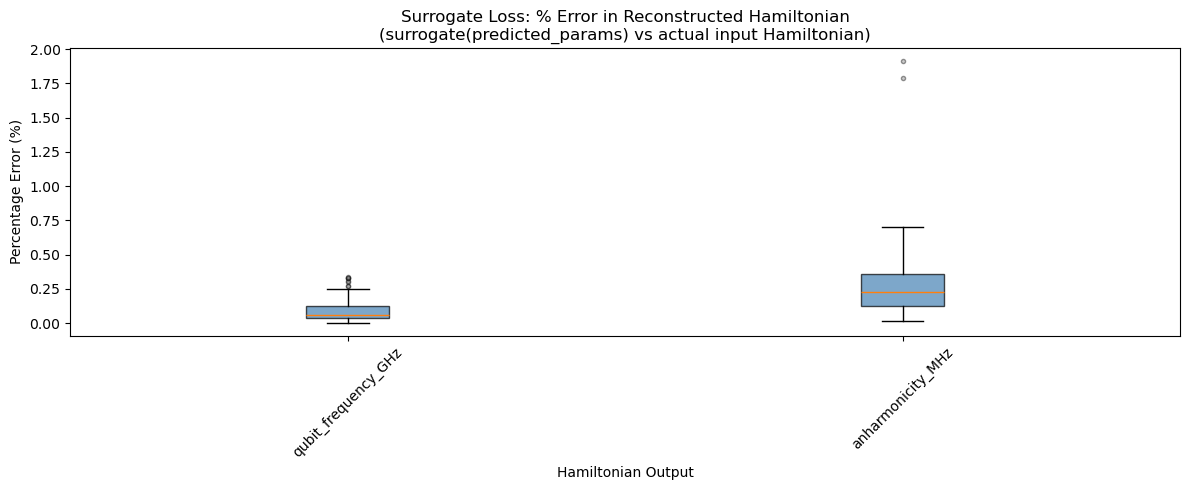

In [12]:
# box plot showing % error distribution per eigenmode output 
fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.boxplot(data_per_col, labels=short_names, patch_artist=True, showfliers=True,
                flierprops=dict(marker='o', markersize=3, alpha=0.4, markerfacecolor='grey'))
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
ax.set_ylabel('Percentage Error (%)')
ax.set_xlabel('eigenmode Output')
ax.set_title('Surrogate Loss: % Error in Reconstructed eigenmode\n(surrogate(predicted_params) vs actual input eigenmode)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('plots/surrogate_loss_eigenmode_recon_pct_error_boxplot.pdf')
plt.show()

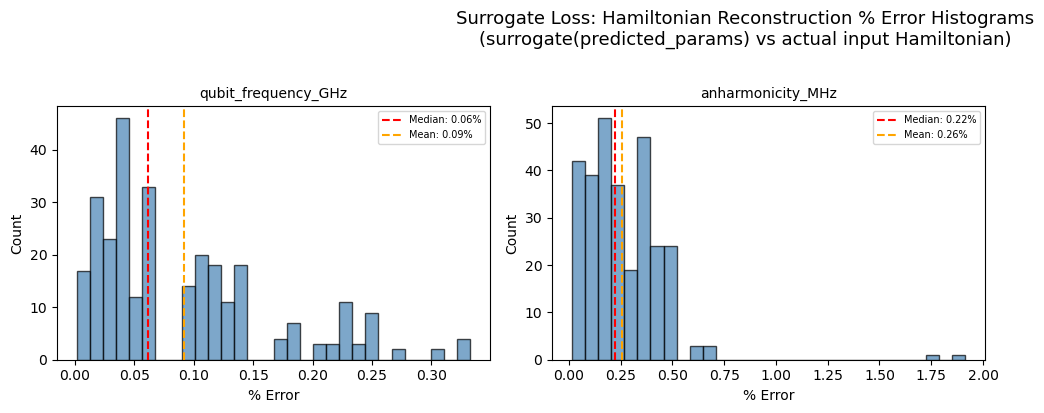

In [13]:
# histogram it too
n_cols_grid = 3
n_rows_grid = math.ceil(n_eigenmode_params / n_cols_grid)

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(5 * n_cols_grid, 4 * n_rows_grid))
axes = axes.ravel()

for j in range(n_eigenmode_params):
    col_pct = pct_errors_unscaled[:, j]
    ax = axes[j]
    ax.hist(col_pct, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(np.median(col_pct), color='red', linestyle='--',
               label=f'Median: {np.median(col_pct):.2f}%')
    ax.axvline(np.mean(col_pct), color='orange', linestyle='--',
               label=f'Mean: {np.mean(col_pct):.2f}%')
    ax.set_title(short_names[j], fontsize=10)
    ax.set_xlabel('% Error')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

for k in range(n_eigenmode_params, len(axes)):
    fig.delaxes(axes[k])

fig.suptitle('Surrogate Loss: eigenmode Reconstruction % Error Histograms\n(surrogate(predicted_params) vs actual input eigenmode)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plots/surrogate_loss_eigenmode_recon_pct_error_histograms.pdf')
plt.show()

In [14]:
#look at the stats nicely
print('eigenmode Reconstruction % Error: surrogate(predicted_params) vs actual input eigenmode')
print()
print(f"{'Output':<25s} {'Median %':>10s} {'Mean %':>10s} {'90th %':>10s} {'Max %':>10s}")
print('-' * 70)
for j in range(n_eigenmode_params):
    col_pct = pct_errors_unscaled[:, j]
    name = short_names[j]
    print(f"{name:<25s} {np.median(col_pct):10.2f} {np.mean(col_pct):10.2f} "
          f"{np.percentile(col_pct, 90):10.2f} {np.max(col_pct):10.2f}")
print('-' * 70)
print(f"{'All outputs':<25s} {np.median(all_pct):10.2f} {np.mean(all_pct):10.2f} "
      f"{np.percentile(all_pct, 90):10.2f} {np.max(all_pct):10.2f}")

Hamiltonian Reconstruction % Error: surrogate(predicted_params) vs actual input Hamiltonian

Output                      Median %     Mean %     90th %      Max %
----------------------------------------------------------------------
qubit_frequency_GHz             0.06       0.09       0.22       0.33
anharmonicity_MHz               0.22       0.26       0.47       1.91
----------------------------------------------------------------------
All outputs                     0.13       0.17       0.38       1.91


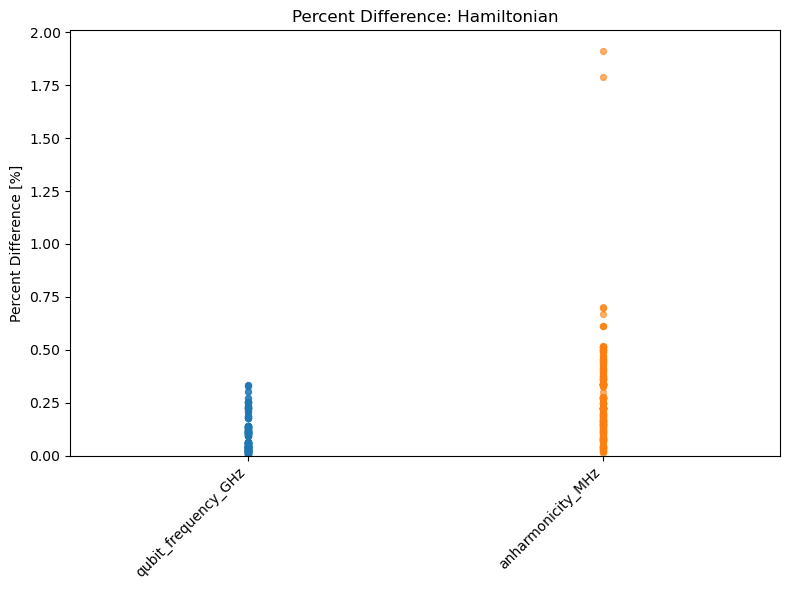

In [15]:
# scatter plot
fig, ax = plt.subplots(figsize=(8, 6))
for j in range(n_eigenmode_params):
    col_pct = pct_errors_unscaled[:, j]
    ax.scatter(np.full(len(col_pct), j), col_pct, s=18, alpha=0.6)
ax.set_xticks(range(n_eigenmode_params))
ax.set_xticklabels(short_names, rotation=45, ha='right')
ax.set_ylabel('Percent Difference [%]')
ax.set_title('Percent Difference: eigenmode')
ax.set_ylim(0, None)
ax.margins(y=0)
ax.set_xlim(-0.5, n_eigenmode_params - 0.5)
plt.tight_layout()
plt.savefig('plots/surrogate_loss_eigenmode_recon_pct_scatter.pdf')
plt.show()

Loaded 94 samples. Columns: ['frequency', 'anharmonicity']
       frequency  anharmonicity
count     94.000         94.000
mean       0.939          2.035
std        0.750          1.620
min        0.004          0.009
25%        0.255          0.556
50%        0.874          1.897
75%        1.425          3.082
max        2.787          6.028


/tmp/ipykernel_39061/3241036953.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


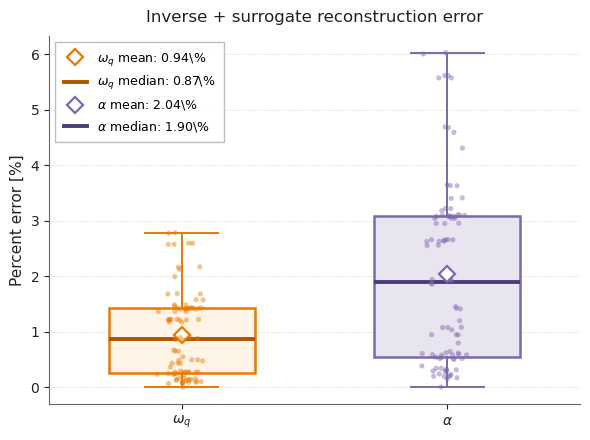

Saved -> plots/inverse_surrogate_percent_error_boxplot.pdf
Saved -> plots/inverse_surrogate_percent_error_boxplot.png


In [16]:
# === Box plot of inverse+surrogate percent errors ================================
# Loads the per-sample % errors on reconstructed qubit frequency and anharmonicity
# and draws a box plot in the same color scheme as generate_workflow_mpl.py.

import pandas as pd
import matplotlib.pyplot as plt

# ---- same palette as generate_workflow_mpl.py -----------------------------------
ORANGE       = "#E87A00"   # physics / qubit accent
ORANGE_LIGHT = "#FFF4E6"
PURPLE       = "#7B68AE"   # validation / cavity accent
PURPLE_LIGHT = "#E8E4F0"
TEXT_MAIN    = "#222222"
ORANGE_DARK  = "#A85600"
PURPLE_DARK  = "#4A3D78"

# ---- load ------------------------------------------------------------------------
err_df = pd.read_csv('inverse+surrogate_percentErrors.csv')
# sanity check: expect columns 'frequency' and 'anharmonicity'
print(f'Loaded {len(err_df)} samples. Columns: {list(err_df.columns)}')
print(err_df.describe().round(3))

data   = [err_df['frequency'].values, err_df['anharmonicity'].values]
labels = [r'$\omega_q$', r'$\alpha$']
colors_face = [ORANGE_LIGHT, PURPLE_LIGHT]
colors_edge = [ORANGE,       PURPLE]
colors_median = [ORANGE_DARK, PURPLE_DARK]

# ---- plot ------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4.5))

bp = ax.boxplot(
    data,
    labels=labels,
    patch_artist=True,        # lets us fill the boxes
    widths=0.55,
    showmeans=True,
    meanprops=dict(marker='D', markerfacecolor='white',
                   markeredgecolor=TEXT_MAIN, markersize=6),
    medianprops=dict(color=TEXT_MAIN, linewidth=1.8),
    flierprops=dict(marker='o', markersize=4,
                    markerfacecolor='none', markeredgecolor='#888888',
                    alpha=0.7),
)

# color each box and its whiskers/caps to match the palette
# color each box, its whiskers/caps, AND its mean/median markers to match the palette
for i, (patch, face, edge) in enumerate(zip(bp['boxes'], colors_face, colors_edge)):
    patch.set_facecolor(face)
    patch.set_edgecolor(edge)
    patch.set_linewidth(1.8)
    # whiskers and caps come in pairs per box
    for whisker in bp['whiskers'][2*i:2*i + 2]:
        whisker.set_color(edge)
        whisker.set_linewidth(1.4)
    for cap in bp['caps'][2*i:2*i + 2]:
        cap.set_color(edge)
        cap.set_linewidth(1.4)
    # median line (one per box)
    # median line — darker shade of the series color, thicker than whiskers/box
    bp['medians'][i].set_color(colors_median[i])
    bp['medians'][i].set_linewidth(2.8)

    # mean diamond (one per box, present because showmeans=True)
    bp['means'][i].set_markeredgecolor(edge)
    bp['means'][i].set_markeredgewidth(1.6)
    bp['means'][i].set_markerfacecolor('white')
    bp['means'][i].set_markersize(8)

# overlay the raw points so the reader can see the distribution, not just the box
import numpy as np
rng = np.random.default_rng(0)
for i, (vals, edge) in enumerate(zip(data, colors_edge)):
    jitter = rng.normal(0, 0.04, size=len(vals))
    ax.scatter(np.full_like(vals, i + 1) + jitter, vals,
               s=14, color=edge, alpha=0.45, zorder=3,
               edgecolor='none')

ax.set_ylabel('Percent error [%]', color=TEXT_MAIN, fontsize=11)
ax.set_title('Inverse + surrogate reconstruction error',
             color=TEXT_MAIN, fontsize=12, pad=10)
ax.tick_params(axis='both', colors=TEXT_MAIN, labelsize=10)
ax.set_axisbelow(True)
ax.grid(axis='y', linestyle=':', linewidth=0.6, color='#BBBBBB', alpha=0.7)
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
for spine in ('left', 'bottom'):
    ax.spines[spine].set_color('#666666')
# ---- legend showing mean and median values --------------------------------------
import numpy as np
from matplotlib.lines import Line2D

means   = [np.mean(vals)   for vals in data]
medians = [np.median(vals) for vals in data]

# Color the proxy markers to match each series (orange = freq, purple = anh).
# Mean diamond keeps a white face but gets a colored edge; median line gets
# a colored body so the two statistics remain distinguishable within a series.
legend_handles = [
    # freq mean
    Line2D([0], [0], marker='D', linestyle='none',
           markerfacecolor='white', markeredgecolor=colors_edge[0],
           markeredgewidth=1.6, markersize=8,
           label=fr'$\omega_q$ mean: {means[0]:.2f}\%'),
    # freq median
    Line2D([0], [0], color=colors_median[0], linewidth=2.8,
           label=fr'$\omega_q$ median: {medians[0]:.2f}\%'),
    # anharmonicity mean
    Line2D([0], [0], marker='D', linestyle='none',
           markerfacecolor='white', markeredgecolor=colors_edge[1],
           markeredgewidth=1.6, markersize=8,
           label=fr'$\alpha$ mean: {means[1]:.2f}\%'),
    # anharmonicity median
    Line2D([0], [0], color=colors_median[1], linewidth=2.8,
           label=fr'$\alpha$ median: {medians[1]:.2f}\%'),
]

ax.legend(
    handles=legend_handles,
    loc='upper left',
    frameon=True,
    fancybox=False,
    edgecolor='#BBBBBB',
    facecolor='white',
    framealpha=0.95,
    fontsize=9,
    handlelength=1.8,
    borderpad=0.7,
    labelspacing=0.5,
)
plt.tight_layout()

# save next to the other paper plots
out_pdf = 'plots/inverse_surrogate_percent_error_boxplot.pdf'
out_png = 'plots/inverse_surrogate_percent_error_boxplot.png'
plt.savefig(out_pdf, bbox_inches='tight')
plt.savefig(out_png, bbox_inches='tight', dpi=200)
plt.show()
print(f'Saved -> {out_pdf}')
print(f'Saved -> {out_png}')


Model architecture: inverse_model
Total layers: 4
Total params: 387
Trainable params: 387
Non-trainable params: 0
----------------------------------------------------------------------------------------


idx,name,type,role,output_shape,units,activation,dropout,params,trainable
0,fc0,Dense,dense,—,64,linear,—,192,True
1,leaky_relu0,LeakyReLU,activation,—,—,—,—,0,True
2,dropout0,Dropout,dropout,—,—,—,0.000,0,True
3,qiskit_output,Dense,dense,—,3,linear,—,195,True


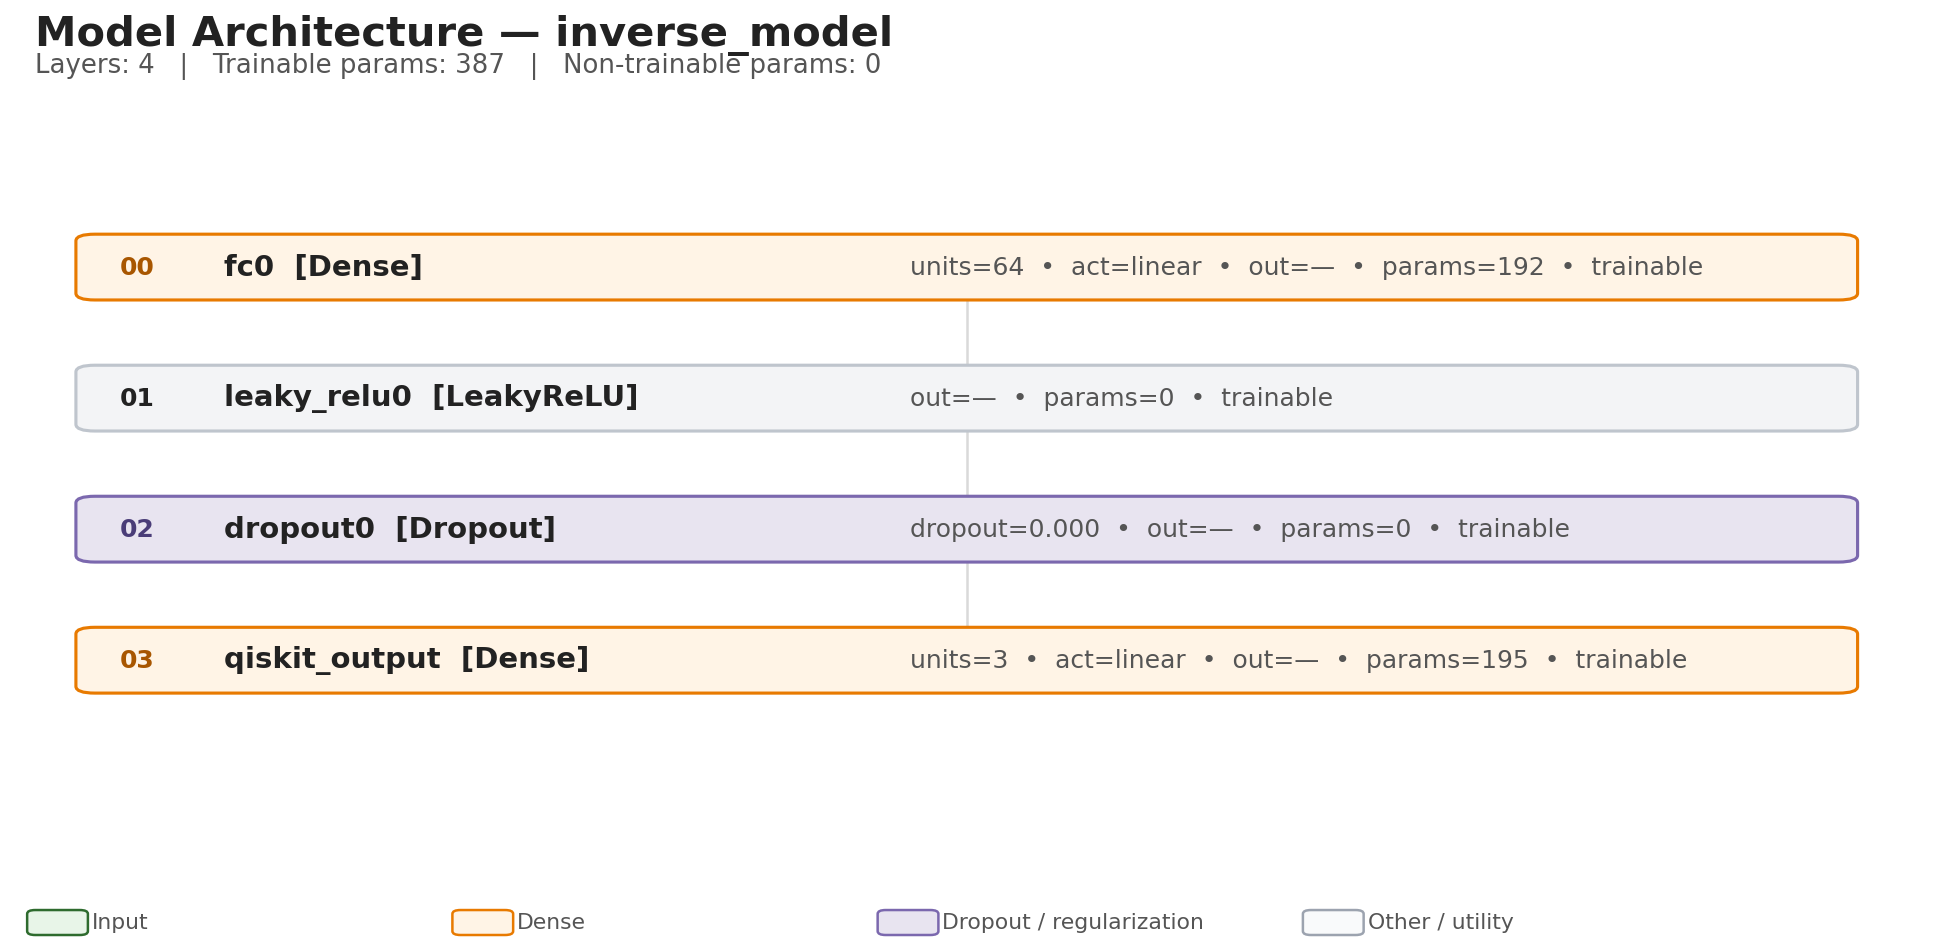


Saved architecture figure -> plots/model_architecture_paper_theme_inverse_model.pdf

Plain Keras summary:



Model: "inverse_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fc0 (Dense)                     │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu0 (LeakyReLU)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout0 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qiskit_output (Dense)           │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 387 (1.51 KB)

 Trainable params: 387 (1.51 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# ============================================================================
# Paper-themed model architecture summary + diagram
# FIXED: title/subtitle placed in figure space, with explicit top margin
# ============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from IPython.display import display

GREEN         = "#3D8B3D"
GREEN_LIGHT   = "#E8F5E8"
GREEN_DARK    = "#2E6B2E"
ORANGE        = "#E87A00"
ORANGE_LIGHT  = "#FFF4E6"
ORANGE_DARK   = "#A85600"
PURPLE        = "#7B68AE"
PURPLE_LIGHT  = "#E8E4F0"
PURPLE_DARK   = "#4A3D78"
TEXT_MAIN     = "#222222"
TEXT_DIM      = "#555555"
GRID_LIGHT    = "#D9D9D9"
BG            = "#FFFFFF"

plt.rcParams.update({
    "text.usetex":      False,
    "mathtext.fontset": "cm",
    "font.family":      "sans-serif",
    "font.sans-serif":  ["Helvetica", "Arial", "DejaVu Sans"],
    "axes.labelcolor":  TEXT_MAIN,
    "xtick.color":      TEXT_MAIN,
    "ytick.color":      TEXT_MAIN,
    "axes.edgecolor":   TEXT_DIM,
    "axes.titlesize":   13,
    "axes.labelsize":   11,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
    "legend.fontsize":  9,
    "figure.dpi":       150,
})

os.makedirs("plots", exist_ok=True)

MODEL_TO_SHOW = inverse_model if "inverse_model" in globals() else combined_model
MODEL_NAME = MODEL_TO_SHOW.name

def _safe_tuple(x):
    try:
        return tuple(x)
    except Exception:
        return x

def _shape_to_str(x):
    if x is None:
        return "—"
    if isinstance(x, list):
        return " / ".join(str(_safe_tuple(v)) for v in x)
    return str(_safe_tuple(x))

def _layer_role(layer):
    name = layer.__class__.__name__.lower()
    if "input" in name:
        return "input"
    if "dense" in name:
        return "dense"
    if "dropout" in name:
        return "dropout"
    if "batchnormalization" in name or "normalization" in name:
        return "norm"
    if "activation" in name or "leakyrelu" in name or "relu" in name:
        return "activation"
    if "scalerconversionlayer" in name:
        return "scaler"
    if "lambda" in name:
        return "transform"
    if "concatenate" in name or "add" in name or "multiply" in name:
        return "merge"
    if "model" in name or "functional" in name or "sequential" in name:
        return "submodel"
    return "other"

ROLE_STYLE = {
    "input":      dict(face=GREEN_LIGHT,  edge=GREEN_DARK,  text=GREEN_DARK),
    "dense":      dict(face=ORANGE_LIGHT, edge=ORANGE,      text=ORANGE_DARK),
    "dropout":    dict(face=PURPLE_LIGHT, edge=PURPLE,      text=PURPLE_DARK),
    "norm":       dict(face="#F3F4F6",    edge="#9CA3AF",   text=TEXT_MAIN),
    "activation": dict(face="#F3F4F6",    edge="#BFC5CD",   text=TEXT_MAIN),
    "scaler":     dict(face="#EEF2FF",    edge=PURPLE,      text=PURPLE_DARK),
    "transform":  dict(face="#F9FAFB",    edge="#6B7280",   text=TEXT_MAIN),
    "merge":      dict(face="#ECFDF5",    edge=GREEN,       text=GREEN_DARK),
    "submodel":   dict(face="#F5F3FF",    edge=PURPLE_DARK, text=PURPLE_DARK),
    "other":      dict(face="#F9FAFB",    edge="#A0A7B2",   text=TEXT_MAIN),
}

rows = []
for i, layer in enumerate(MODEL_TO_SHOW.layers):
    role = _layer_role(layer)
    units = getattr(layer, "units", "")
    activation = getattr(layer, "activation", None)
    activation_name = getattr(activation, "__name__", "") if activation is not None else ""
    rate = getattr(layer, "rate", "")
    params = int(layer.count_params())

    rows.append({
        "idx": i,
        "name": layer.name,
        "type": layer.__class__.__name__,
        "role": role,
        "output_shape": _shape_to_str(getattr(layer, "output_shape", None)),
        "units": units if units != "" else "—",
        "activation": activation_name if activation_name else "—",
        "dropout": f"{float(rate):.3f}" if rate != "" else "—",
        "params": params,
        "trainable": bool(getattr(layer, "trainable", True)),
    })

arch_df = pd.DataFrame(rows)

print(f"\n{'='*88}")
print(f"Model architecture: {MODEL_NAME}")
print(f"{'='*88}")
print(f"Total layers: {len(MODEL_TO_SHOW.layers)}")
print(f"Total params: {MODEL_TO_SHOW.count_params():,}")

trainable_params = int(np.sum(
    [np.prod(v.shape) for v in MODEL_TO_SHOW.trainable_weights]
)) if MODEL_TO_SHOW.trainable_weights else 0
non_trainable_params = int(np.sum(
    [np.prod(v.shape) for v in MODEL_TO_SHOW.non_trainable_weights]
)) if MODEL_TO_SHOW.non_trainable_weights else 0

print(f"Trainable params: {trainable_params:,}")
print(f"Non-trainable params: {non_trainable_params:,}")
print(f"{'-'*88}")

display(
    arch_df.style
    .hide(axis="index")
    .format({"params": "{:,}"})
    .set_properties(**{
        "color": TEXT_MAIN,
        "border-color": GRID_LIGHT,
        "font-size": "10pt",
    })
    .set_table_styles([
        {"selector": "th", "props": [
            ("background-color", GREEN_DARK),
            ("color", "white"),
            ("font-weight", "bold"),
            ("border", f"1px solid {GRID_LIGHT}"),
            ("padding", "6px")
        ]},
        {"selector": "td", "props": [
            ("padding", "6px"),
            ("border", f"1px solid {GRID_LIGHT}")
        ]},
        {"selector": "table", "props": [
            ("border-collapse", "collapse"),
            ("font-family", "Helvetica, Arial, sans-serif")
        ]},
    ])
)

# ---------------------------------------------------------------------------
# Figure
# ---------------------------------------------------------------------------
n = len(arch_df)
fig_h = max(5.2, 1.15 * n + 1.8)
fig, ax = plt.subplots(figsize=(13.5, fig_h))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.axis("off")

# IMPORTANT: reserve figure-level space for header and legend
fig.subplots_adjust(left=0.04, right=0.98, top=0.84, bottom=0.14)

# Put title/subtitle in FIGURE coordinates, not AXES coordinates
fig.text(
    0.05, 0.965,
    f"Model Architecture — {MODEL_NAME}",
    ha="left", va="top",
    fontsize=20, fontweight="bold", color=TEXT_MAIN
)
fig.text(
    0.05, 0.925,
    f"Layers: {len(MODEL_TO_SHOW.layers)}   |   "
    f"Trainable params: {trainable_params:,}   |   "
    f"Non-trainable params: {non_trainable_params:,}",
    ha="left", va="top",
    fontsize=12.5, color=TEXT_DIM
)

left = 0.04
width = 0.92
top = 0.90
bottom = 0.12
usable_h = top - bottom

gap = usable_h / max(n, 1)
box_h = min(0.09, gap * 0.42)

for i, row in arch_df.iterrows():
    y_center = top - (i + 0.5) * gap
    y = y_center - box_h / 2.0
    style = ROLE_STYLE.get(row["role"], ROLE_STYLE["other"])

    box = FancyBboxPatch(
        (left, y), width, box_h,
        boxstyle="round,pad=0.008,rounding_size=0.01",
        linewidth=1.5,
        edgecolor=style["edge"],
        facecolor=style["face"],
        transform=ax.transAxes
    )
    ax.add_patch(box)

    ax.text(
        left + 0.015, y + box_h / 2,
        f"{int(row['idx']):02d}",
        transform=ax.transAxes,
        ha="left", va="center",
        fontsize=12, fontweight="bold", color=style["text"]
    )

    ax.text(
        left + 0.07, y + box_h / 2,
        f"{row['name']}  [{row['type']}]",
        transform=ax.transAxes,
        ha="left", va="center",
        fontsize=14, fontweight="bold", color=TEXT_MAIN
    )

    details = []
    if row["units"] != "—":
        details.append(f"units={row['units']}")
    if row["activation"] != "—":
        details.append(f"act={row['activation']}")
    if row["dropout"] != "—":
        details.append(f"dropout={row['dropout']}")
    details.append(f"out={row['output_shape']}")
    details.append(f"params={row['params']:,}")
    details.append("trainable" if row["trainable"] else "frozen")

    ax.text(
        left + 0.43, y + box_h / 2,
        "  •  ".join(details),
        transform=ax.transAxes,
        ha="left", va="center",
        fontsize=12, color=TEXT_DIM
    )

    if i < n - 1:
        next_y_center = top - (i + 1.5) * gap
        xmid = left + width / 2
        ax.plot(
            [xmid, xmid],
            [y - 0.008, next_y_center + box_h / 2 + 0.008],
            transform=ax.transAxes,
            color=GRID_LIGHT,
            linewidth=1.2,
            zorder=0
        )

legend_items = [
    ("Input", GREEN_LIGHT, GREEN_DARK),
    ("Dense", ORANGE_LIGHT, ORANGE),
    ("Dropout / regularization", PURPLE_LIGHT, PURPLE),
    ("Other / utility", "#F9FAFB", "#9CA3AF"),
]

x0 = 0.05
y0 = 0.01
dx = 0.21

for k, (label, face, edge) in enumerate(legend_items):
    xx = x0 + k * dx
    rect = FancyBboxPatch(
        (xx, y0), 0.022, 0.018,
        boxstyle="round,pad=0.004,rounding_size=0.004",
        transform=fig.transFigure,
        facecolor=face, edgecolor=edge, linewidth=1.2
    )
    fig.add_artist(rect)
    fig.text(
        xx + 0.028, y0 + 0.009, label,
        ha="left", va="center",
        fontsize=10.5, color=TEXT_DIM
    )

out_path = f"plots/model_architecture_paper_theme_{MODEL_NAME}.pdf"
plt.savefig(out_path, dpi=300)   # no tight_layout, no bbox_inches="tight"
plt.show()

print(f"\nSaved architecture figure -> {out_path}")
print("\nPlain Keras summary:\n")
MODEL_TO_SHOW.summary()

Found 549 trial.json files under kt_dir2
Loaded 549 completed trials

Best trial:  val_loss = 0.0008
    n_layers            1
    neurons_0           64
    neurons_1           768
    dropout_rate        0.0
    l2_reg              1e-06
    learning_rate       0.00540136975658082
    use_batchnorm       False
    penalty_weight      0.029924019032936792
    neurons_2           64
    neurons_3           1024.0
    total_params        387


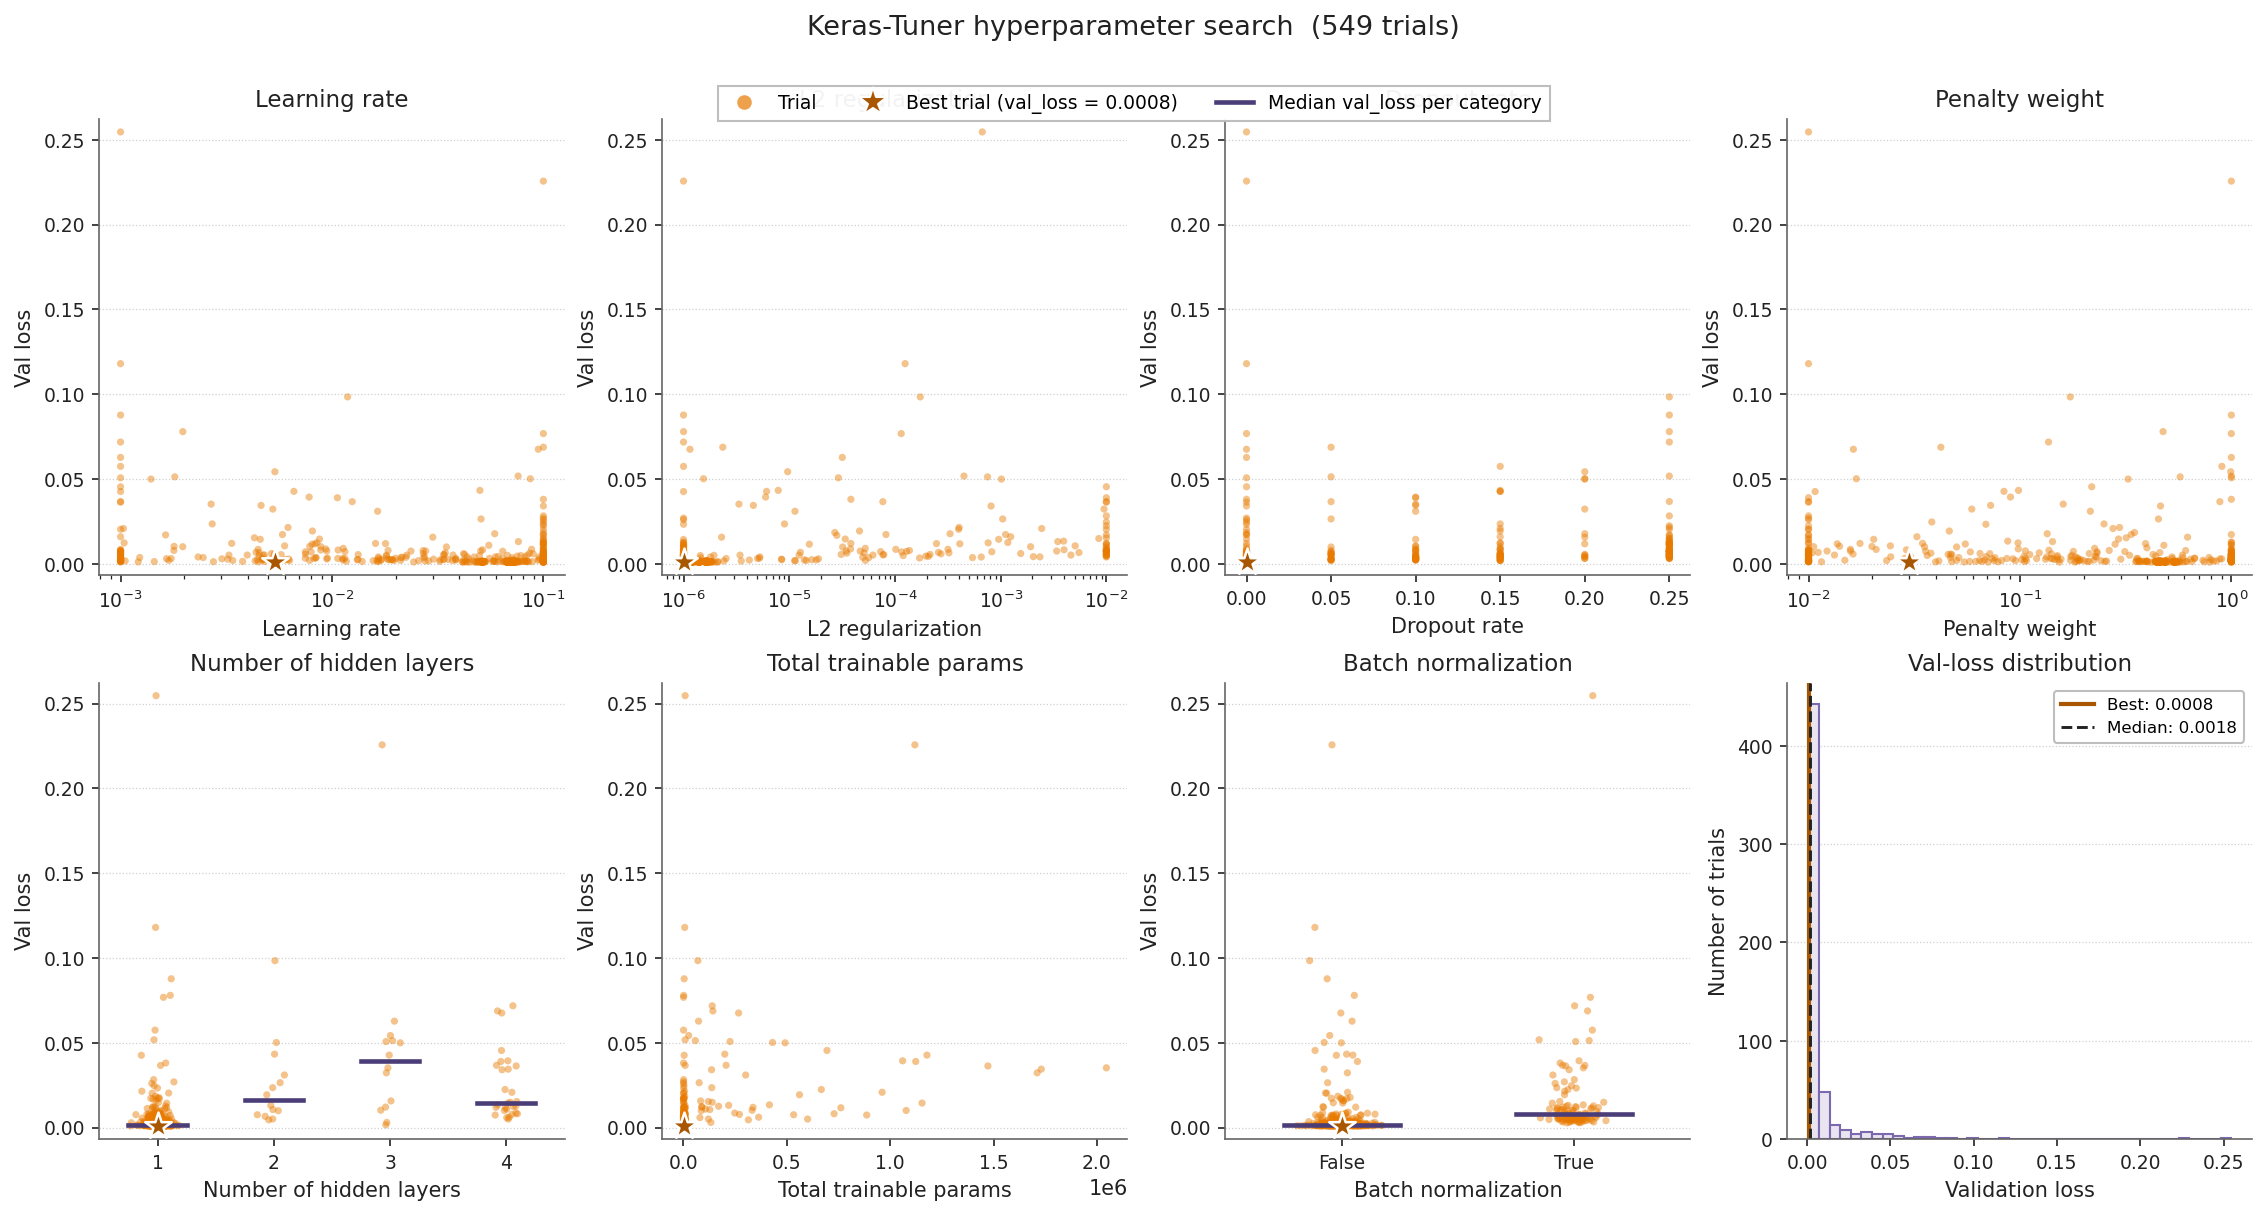

Saved plots/keras_tuner_hyperparameter_search.{pdf,png}


In [18]:
# =====================================================================
# Hyperparameter search visualization (Keras Tuner results)
#
# Loads all trial.json files written by Keras Tuner under kt_dir2 and
# plots val_loss as a function of each tuned hyperparameter, using
# small multiples (2D panels) instead of a 3D scatter - NMI and most
# modern journals strongly prefer 2D over 3D since 3D plots suffer from
# occlusion, don't print well, and lose information when the figure is
# static (as it will be in the PDF).
#
# Color palette and axis styling match generate_workflow_mpl.py / the
# other figures in this notebook.
# =====================================================================

import os, json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---- palette (matches generate_workflow_mpl.py) ----------------------
ORANGE       = "#E87A00"
ORANGE_LIGHT = "#FFF4E6"
ORANGE_DARK  = "#A85600"
PURPLE       = "#7B68AE"
PURPLE_LIGHT = "#E8E4F0"
PURPLE_DARK  = "#4A3D78"
TEXT_MAIN    = "#222222"

# ---- load every completed trial from the Keras-Tuner directory ------
KT_PROJECT_DIR = 'kt_dir2/transmon_cross_surrogate_loss2'
trial_files = sorted(glob.glob(os.path.join(KT_PROJECT_DIR, 'trial_*', 'trial.json')))
if not trial_files:
    trial_files = sorted(glob.glob('kt_dir2/**/trial.json', recursive=True))
print(f'Found {len(trial_files)} trial.json files under kt_dir2')

rows = []
for fp in trial_files:
    try:
        with open(fp, 'r') as f:
            t = json.load(f)
    except (json.JSONDecodeError, OSError):
        continue
    if t.get('status', 'COMPLETED') not in ('COMPLETED',):
        continue
    score = t.get('score', None)
    if score is None:
        continue
    hp_vals = (t.get('hyperparameters', {}) or {}).get('values', {}) or {}
    row = {'trial_id': t.get('trial_id', ''), 'val_loss': float(score)}
    row.update(hp_vals)
    rows.append(row)

df_tr = pd.DataFrame(rows)
print(f'Loaded {len(df_tr)} completed trials')
if len(df_tr) == 0:
    raise SystemExit('No completed trials found - nothing to plot.')

# Derive total-parameter count (what the 3D figure's y-axis was).
eigenmode_dim_guess = 2   # fq, alpha
qiskit_dim_guess      = 3   # claw_length, ground_spacing, cross_length

def _total_params(row):
    n_layers = int(row.get('n_layers', 0) or 0)
    prev, total = eigenmode_dim_guess, 0
    for i in range(n_layers):
        n_i = int(row.get(f'neurons_{i}', 0) or 0)
        total += prev * n_i + n_i
        if bool(row.get('use_batchnorm', False)):
            total += 2 * n_i
        prev = n_i
    total += prev * qiskit_dim_guess + qiskit_dim_guess
    return total

df_tr['total_params'] = df_tr.apply(_total_params, axis=1)

best_idx = df_tr['val_loss'].idxmin()
best = df_tr.loc[best_idx]
print(f"\nBest trial:  val_loss = {best['val_loss']:.4f}")
for col in df_tr.columns:
    if col not in ('trial_id', 'val_loss'):
        print(f"    {col:18s}  {best[col]}")

# ---- plot: small multiples, one panel per hyperparameter -------------
PANELS = [
    ('learning_rate',  'Learning rate',            True,  'scatter'),
    ('l2_reg',         'L2 regularization',        True,  'scatter'),
    ('dropout_rate',   'Dropout rate',             False, 'scatter'),
    ('penalty_weight', 'Penalty weight',           True,  'scatter'),
    ('n_layers',       'Number of hidden layers',  False, 'strip'),
    ('total_params',   'Total trainable params',   False, 'scatter'),
    ('use_batchnorm',  'Batch normalization',      False, 'strip'),
    ('__summary__',    'Val-loss distribution',    False, 'hist'),
]

fig, axes = plt.subplots(2, 4, figsize=(15, 7.5), constrained_layout=True)
axes = axes.ravel()

vloss = df_tr['val_loss'].to_numpy()
vmin, vmax = vloss.min(), vloss.max()
ylim = (vmin - 0.03 * (vmax - vmin), vmax + 0.03 * (vmax - vmin))
rng = np.random.default_rng(0)

for ax, (col, label, use_log, kind) in zip(axes, PANELS):
    ax.set_axisbelow(True)
    ax.grid(axis='y', linestyle=':', linewidth=0.6, color='#BBBBBB', alpha=0.7)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
    for spine in ('left', 'bottom'):
        ax.spines[spine].set_color('#666666')
    ax.tick_params(axis='both', colors=TEXT_MAIN, labelsize=9)

    if kind == 'hist':
        ax.hist(vloss, bins=40, color=PURPLE_LIGHT, edgecolor=PURPLE, linewidth=1.0)
        ax.axvline(best['val_loss'], color=ORANGE_DARK, linewidth=2.0,
                   label=f"Best: {best['val_loss']:.4f}")
        ax.axvline(np.median(vloss), color=TEXT_MAIN, linewidth=1.4,
                   linestyle='--', label=f"Median: {np.median(vloss):.4f}")
        ax.set_xlabel('Validation loss', color=TEXT_MAIN, fontsize=10)
        ax.set_ylabel('Number of trials', color=TEXT_MAIN, fontsize=10)
        ax.set_title(label, color=TEXT_MAIN, fontsize=11, pad=6)
        ax.legend(fontsize=8, frameon=True, edgecolor='#BBBBBB', framealpha=0.95)
        continue

    if col not in df_tr.columns:
        ax.set_title(f"{label}  (not in trials)", color='#888888', fontsize=11, pad=6)
        ax.set_xticks([]); ax.set_yticks([])
        continue

    xvals = df_tr[col].to_numpy()

    if kind == 'strip':
        cats = sorted(np.unique(xvals).tolist(), key=lambda v: (isinstance(v, bool), v))
        cat_to_x = {c: i for i, c in enumerate(cats)}
        x_plot = np.array([cat_to_x[v] for v in xvals], dtype=float)
        x_plot += rng.normal(0, 0.06, size=x_plot.shape)
        ax.scatter(x_plot, vloss, s=12, color=ORANGE, alpha=0.45,
                   edgecolor='none', zorder=2)
        for c in cats:
            m = np.median(vloss[xvals == c])
            ax.plot([cat_to_x[c] - 0.25, cat_to_x[c] + 0.25], [m, m],
                    color=PURPLE_DARK, linewidth=2.2, zorder=3)
        b_x = cat_to_x[best[col]]
        ax.scatter([b_x], [best['val_loss']], marker='*',
                   s=180, color=ORANGE_DARK, edgecolor='white',
                   linewidths=1.2, zorder=5)
        ax.set_xticks(list(cat_to_x.values()))
        ax.set_xticklabels([str(c) for c in cats])
        ax.set_xlim(-0.5, len(cats) - 0.5)
    else:
        ax.scatter(xvals, vloss, s=12, color=ORANGE, alpha=0.45,
                   edgecolor='none', zorder=2)
        ax.scatter([best[col]], [best['val_loss']], marker='*',
                   s=180, color=ORANGE_DARK, edgecolor='white',
                   linewidths=1.2, zorder=5)
        if use_log:
            ax.set_xscale('log')

    ax.set_xlabel(label, color=TEXT_MAIN, fontsize=10)
    ax.set_ylabel('Val loss', color=TEXT_MAIN, fontsize=10)
    ax.set_title(label, color=TEXT_MAIN, fontsize=11, pad=6)
    ax.set_ylim(ylim)

legend_handles = [
    Line2D([0], [0], marker='o', linestyle='none', markerfacecolor=ORANGE,
           markeredgecolor='none', markersize=7, alpha=0.7, label='Trial'),
    Line2D([0], [0], marker='*', linestyle='none', markerfacecolor=ORANGE_DARK,
           markeredgecolor='white', markeredgewidth=1.0, markersize=14,
           label=f"Best trial (val_loss = {best['val_loss']:.4f})"),
    Line2D([0], [0], color=PURPLE_DARK, linewidth=2.2,
           label='Median val_loss per category'),
]
fig.legend(handles=legend_handles, loc='upper center',
           bbox_to_anchor=(0.5, 1.005), ncol=3, frameon=True, fancybox=False,
           edgecolor='#BBBBBB', facecolor='white', framealpha=0.95, fontsize=9)

fig.suptitle(f'Keras-Tuner hyperparameter search  ({len(df_tr)} trials)',
             color=TEXT_MAIN, fontsize=13, y=1.06)

os.makedirs('plots', exist_ok=True)
plt.savefig('plots/keras_tuner_hyperparameter_search.pdf', bbox_inches='tight')
plt.savefig('plots/keras_tuner_hyperparameter_search.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved plots/keras_tuner_hyperparameter_search.{pdf,png}')

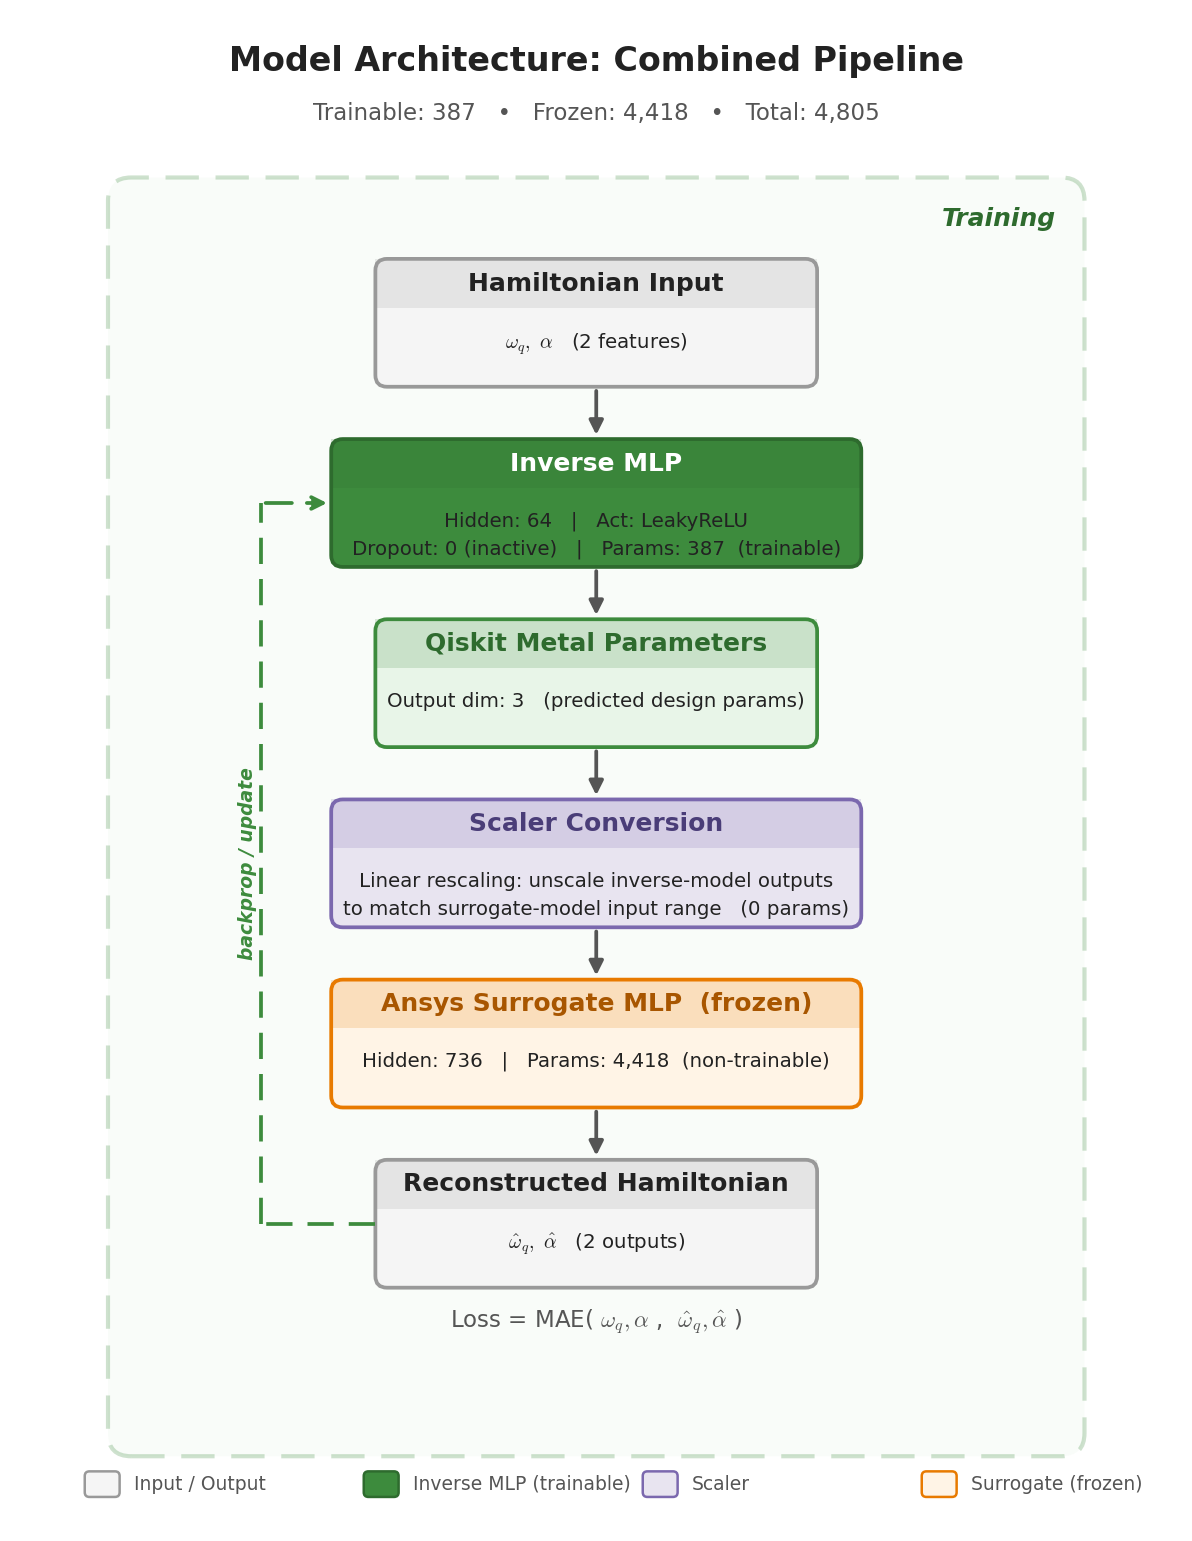


Saved → plots/model_architecture_paper_theme_combined.pdf
Saved → plots/model_architecture_paper_theme_combined.png


In [19]:
# ============================================================================
# Paper-themed model architecture diagram
# Matches the visual style of paper_plots/ (workflow, inverse_pipeline, etc.)
#
# Paste this cell at the end of ml_22_print_results_surrogate_defined_loss.ipynb
# It requires `combined_model` and `inverse_model` to already be loaded.
# ============================================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle
from tensorflow.keras.layers import Dense

# ---- Color palette (matches paper_plots/) --------------------------------
GREEN         = "#3D8B3D"
GREEN_LIGHT   = "#E8F5E8"
GREEN_DARK    = "#2E6B2E"

ORANGE        = "#E87A00"
ORANGE_LIGHT  = "#FFF4E6"
ORANGE_DARK   = "#A85600"

PURPLE        = "#7B68AE"
PURPLE_LIGHT  = "#E8E4F0"
PURPLE_DARK   = "#4A3D78"

NEUTRAL_FILL  = "#F5F5F5"
NEUTRAL_STROKE = "#999999"

TEXT_MAIN     = "#222222"
TEXT_DIM      = "#555555"
ARROW_COL     = "#555555"

plt.rcParams.update({
    "text.usetex":      False,
    "mathtext.fontset": "cm",
    "font.family":      "sans-serif",
    "font.sans-serif":  ["Helvetica", "Arial", "DejaVu Sans"],
})

# ---- Extract architecture from the live models --------------------------
inv = combined_model.get_layer("inverse_model")

inv_neurons = [
    l.units for l in inv.layers if isinstance(l, Dense) and l.name.startswith("fc")
]
inv_dropout_rates = [
    float(l.rate) for l in inv.layers
    if isinstance(l, tf.keras.layers.Dropout)
]
inv_activation = "LeakyReLU"
inv_input_dim  = combined_model.input_shape[-1]     # 2
inv_output_dim = inv.output_shape[-1]               # 3

surr = None
for layer in combined_model.layers:
    if layer.name not in ("combined_input", "inverse_model", "scaler_conversion"):
        if hasattr(layer, "layers"):
            surr = layer
            break

surr_neurons = []
surr_output_dim = None
if surr is not None:
    surr_neurons = [l.units for l in surr.layers if isinstance(l, Dense)]
    surr_output_dim = surr.output_shape[-1]

trainable_params = int(np.sum(
    [np.prod(v.shape) for v in combined_model.trainable_weights]
)) if combined_model.trainable_weights else 0
frozen_params = int(np.sum(
    [np.prod(v.shape) for v in combined_model.non_trainable_weights]
)) if combined_model.non_trainable_weights else 0

# ---- Define the blocks to draw ------------------------------------------
BLOCK_STYLE = {
    "input":      dict(fill=NEUTRAL_FILL, stroke=NEUTRAL_STROKE, text=TEXT_MAIN),
    "ml":         dict(fill=GREEN_LIGHT,  stroke=GREEN,          text=GREEN_DARK),
    "ml_solid":   dict(fill=GREEN,        stroke=GREEN_DARK,     text="#FFFFFF"),
    "scaler":     dict(fill=PURPLE_LIGHT, stroke=PURPLE,         text=PURPLE_DARK),
    "surrogate":  dict(fill=ORANGE_LIGHT, stroke=ORANGE,         text=ORANGE_DARK),
    "output":     dict(fill=NEUTRAL_FILL, stroke=NEUTRAL_STROKE, text=TEXT_MAIN),
}

inv_hidden_str = " → ".join(str(n) for n in inv_neurons)
dropout_str    = ", ".join(f"{r:.1%}" for r in inv_dropout_rates)
if all(r == 0 for r in inv_dropout_rates):
    dropout_str = "0 (inactive)"

surr_hidden_str = " → ".join(str(n) for n in surr_neurons[:-1]) if surr_neurons else "—"

blocks = [
    {
        "label": "eigenmode Input",
        "lines": [
            rf"$\omega_q,\ \alpha$   (2 features)",
        ],
        "cat": "input",
        "width": 1.0,
    },
    {
        "label": "Inverse MLP",
        "lines": [
            f"Hidden: {inv_hidden_str}   |   Act: {inv_activation}",
            f"Dropout: {dropout_str}   |   Params: {trainable_params:,}  (trainable)",
        ],
        "cat": "ml_solid",
        "width": 1.2,
    },
    {
        "label": f"Qiskit Metal Parameters",
        "lines": [
            f"Output dim: {inv_output_dim}   (predicted design params)",
        ],
        "cat": "ml",
        "width": 1.0,
    },
    {
        "label": "Scaler Conversion",
        "lines": [
            "Linear rescaling: unscale inverse-model outputs",
            "to match surrogate-model input range   (0 params)",
        ],
        "cat": "scaler",
        "width": 1.2,
    },
    {
        "label": "Ansys Surrogate MLP  (frozen)",
        "lines": [
            f"Hidden: {surr_hidden_str}   |   Params: {frozen_params:,}  (non-trainable)" if surr else "—",
        ],
        "cat": "surrogate",
        "width": 1.2,
    },
    {
        "label": "Reconstructed eigenmode",
        "lines": [
            rf"$\hat{{\omega}}_q,\ \hat{{\alpha}}$   ({surr_output_dim} outputs)" if surr_output_dim else "—",
        ],
        "cat": "output",
        "width": 1.0,
    },
]

# ---- Layout (same coordinate approach as generate_workflow_mpl.py) -------
FIG_W, FIG_H = 10, 14
W, H = 100, 130

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.set_xlim(0, W)
ax.set_ylim(0, H)
ax.set_aspect("equal")
ax.axis("off")

# Title
ax.text(
    W / 2, H - 4,
    "Model Architecture: Combined Pipeline",
    ha="center", va="center",
    fontsize=16, fontweight="bold", color=TEXT_MAIN,
)
ax.text(
    W / 2, H - 8.5,
    f"Trainable: {trainable_params:,}   •   "
    f"Frozen: {frozen_params:,}   •   "
    f"Total: {trainable_params + frozen_params:,}",
    ha="center", va="center",
    fontsize=11, color=TEXT_DIM,
)

# Dashed "Training" container
CONTAINER_X = 8
CONTAINER_W = W - 16
CONTAINER_TOP = H - 14
CONTAINER_BOT = 6
CONTAINER_H = CONTAINER_TOP - CONTAINER_BOT

container = FancyBboxPatch(
    (CONTAINER_X, CONTAINER_BOT), CONTAINER_W, CONTAINER_H,
    boxstyle="round,pad=0,rounding_size=2.0",
    linewidth=2.0,
    edgecolor=GREEN,
    facecolor=GREEN_LIGHT,
    alpha=0.25,
    linestyle=(0, (8, 4)),
)
ax.add_patch(container)

ax.text(
    CONTAINER_X + CONTAINER_W - 2.5, CONTAINER_TOP - 2.5,
    "Training",
    ha="right", va="top",
    fontsize=12, fontweight="bold", fontstyle="italic",
    color=GREEN_DARK,
)

# Draw blocks
n_blocks = len(blocks)
CX = W / 2
BOX_W_BASE = 38
BOX_H = 11
TITLE_BAR_H = 4.2
GAP = 4.5

y_start = CONTAINER_TOP - 7

box_positions = []
for i, blk in enumerate(blocks):
    bw = BOX_W_BASE * blk["width"]
    bx = CX - bw / 2
    by = y_start - i * (BOX_H + GAP) - BOX_H
    box_positions.append((bx, by, bw, BOX_H))

for i, (blk, (bx, by, bw, bh)) in enumerate(zip(blocks, box_positions)):
    style = BLOCK_STYLE[blk["cat"]]

    box = FancyBboxPatch(
        (bx, by), bw, bh,
        boxstyle="round,pad=0,rounding_size=1.0",
        linewidth=1.8,
        edgecolor=style["stroke"],
        facecolor=style["fill"],
    )
    ax.add_patch(box)

    bar = Rectangle(
        (bx, by + bh - TITLE_BAR_H), bw, TITLE_BAR_H,
        linewidth=0,
        facecolor=style["stroke"],
        alpha=0.18,
        clip_on=True,
    )
    ax.add_patch(bar)

    ax.text(
        bx + bw / 2, by + bh - TITLE_BAR_H / 2,
        blk["label"],
        ha="center", va="center",
        fontsize=12, fontweight="bold", color=style["text"],
    )

    line_dy = 2.4
    body_top = by + bh - TITLE_BAR_H - 2.0
    for j, line in enumerate(blk["lines"]):
        ax.text(
            bx + bw / 2, body_top - j * line_dy,
            line,
            ha="center", va="top",
            fontsize=9.5, color=TEXT_MAIN,
        )

# Forward arrows
for i in range(n_blocks - 1):
    _, by_a, _, bh_a = box_positions[i]
    _, by_b, _, bh_b = box_positions[i + 1]
    arrow = FancyArrowPatch(
        (CX, by_a),
        (CX, by_b + bh_b),
        arrowstyle="-|>",
        mutation_scale=14,
        linewidth=1.8,
        color=ARROW_COL,
    )
    ax.add_patch(arrow)

# Feedback loop (loss backprop)
_, by_top, bw_top, bh_top = box_positions[1]
_, by_bot, bw_bot, bh_bot = box_positions[-1]
fb_x = box_positions[1][0] - 6

ax.plot(
    [box_positions[-1][0], fb_x],
    [by_bot + bh_bot / 2, by_bot + bh_bot / 2],
    color=GREEN, linewidth=1.8, linestyle=(0, (7, 4)),
)
ax.plot(
    [fb_x, fb_x],
    [by_bot + bh_bot / 2, by_top + bh_top / 2],
    color=GREEN, linewidth=1.8, linestyle=(0, (7, 4)),
)
fb_arrow = FancyArrowPatch(
    (fb_x, by_top + bh_top / 2),
    (box_positions[1][0], by_top + bh_top / 2),
    arrowstyle="-|>",
    mutation_scale=14,
    linewidth=1.8,
    color=GREEN,
    linestyle=(0, (7, 4)),
)
ax.add_patch(fb_arrow)

ax.text(
    fb_x - 1.2,
    (by_bot + bh_bot / 2 + by_top + bh_top / 2) / 2,
    "backprop / update",
    rotation=90, ha="center", va="center",
    fontsize=9, fontweight="bold", fontstyle="italic",
    color=GREEN,
)

# Loss annotation
loss_y = box_positions[-1][1] - 3
ax.text(
    CX, loss_y,
    r"Loss = MAE( $\omega_q, \alpha$ ,  $\hat{\omega}_q, \hat{\alpha}$ )",
    ha="center", va="center",
    fontsize=11, color=TEXT_DIM,
)

# Legend
legend_items = [
    ("Input / Output",     NEUTRAL_FILL, NEUTRAL_STROKE),
    ("Inverse MLP (trainable)", GREEN, GREEN_DARK),
    ("Scaler",             PURPLE_LIGHT, PURPLE),
    ("Surrogate (frozen)", ORANGE_LIGHT, ORANGE),
]

legend_y = 2.5
legend_x_start = 6
dx = 24

for k, (label, face, edge) in enumerate(legend_items):
    xx = legend_x_start + k * dx
    rect = FancyBboxPatch(
        (xx, legend_y), 3, 2.2,
        boxstyle="round,pad=0,rounding_size=0.4",
        linewidth=1.2,
        facecolor=face, edgecolor=edge,
    )
    ax.add_patch(rect)
    ax.text(
        xx + 4.2, legend_y + 1.1, label,
        ha="left", va="center",
        fontsize=9, color=TEXT_DIM,
    )

# Save
out_dir = "plots"
os.makedirs(out_dir, exist_ok=True)
out_pdf = os.path.join(out_dir, "model_architecture_paper_theme_combined.pdf")
out_png = os.path.join(out_dir, "model_architecture_paper_theme_combined.png")

plt.savefig(out_pdf, bbox_inches="tight", pad_inches=0.15)
plt.savefig(out_png, bbox_inches="tight", pad_inches=0.15, dpi=300)
plt.show()

print(f"\nSaved → {out_pdf}")
print(f"Saved → {out_png}")
